In [13]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('Libraries loaded!')

Libraries loaded!


In [14]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DailyDelhiClimateTrain.csv')

print('Shape:', df.shape)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (1462, 5)
         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000


In [15]:
# Check missing values and basic statistics
print('Missing values:')
print(df.isnull().sum())

print('\nBasic stats:')
print(df.describe())

Missing values:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Basic stats:
          meantemp     humidity   wind_speed  meanpressure
count  1462.000000  1462.000000  1462.000000   1462.000000
mean     25.495521    60.771702     6.802209   1011.104548
std       7.348103    16.769652     4.561602    180.231668
min       6.000000    13.428571     0.000000     -3.041667
25%      18.857143    50.375000     3.475000   1001.580357
50%      27.714286    62.625000     6.221667   1008.563492
75%      31.305804    72.218750     9.238235   1014.944901
max      38.714286   100.000000    42.220000   7679.333333


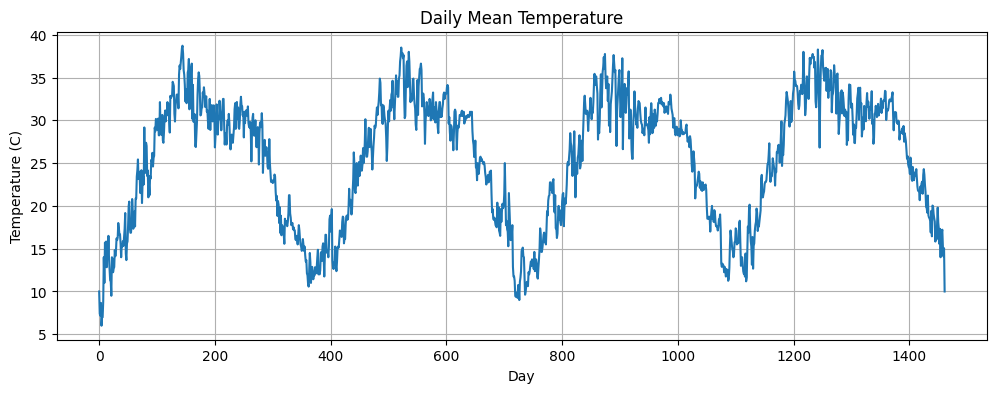

In [16]:
# Plot temperature over time
plt.figure(figsize=(12, 4))
plt.plot(df['meantemp'])
plt.title('Daily Mean Temperature')
plt.xlabel('Day')
plt.ylabel('Temperature (C)')
plt.grid(True)
plt.savefig('temperature_plot.png')
plt.show()

In [17]:
# Normalize data to range [0, 1]
data = df['meantemp'].values.reshape(-1, 1)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

print('Data normalized!')

Data normalized!


In [18]:
# Create sliding window: last 7 days -> next day
def create_sequences(data, window=7):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, window=7)
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (1455, 7, 1)
y shape: (1455, 1)


In [19]:
# Split into train / validation / test
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]

print('Train:', len(X_train), '| Val:', len(X_val), '| Test:', len(X_test))

Train: 1018 | Val: 218 | Test: 219


In [20]:
# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

print('Tensors ready!')

Tensors ready!


In [21]:
# Define Simple RNN model (baseline)
class SimpleRNN(nn.Module):
    def __init__(self):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=32, batch_first=True)
        self.fc  = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # take output of last timestep
        return out

model = SimpleRNN()
print(model)

SimpleRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [22]:
# Train the RNN
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 50
train_losses = []
val_losses   = []

for epoch in range(EPOCHS):
    # Training step
    model.train()
    pred_train = model(X_train_t)
    loss_train = criterion(pred_train, y_train_t)
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    # Validation step
    model.eval()
    with torch.no_grad():
        pred_val = model(X_val_t)
        loss_val = criterion(pred_val, y_val_t)

    train_losses.append(loss_train.item())
    val_losses.append(loss_val.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Train: {loss_train.item():.4f} | Val: {loss_val.item():.4f}')

Epoch 10/50 | Train: 0.1846 | Val: 0.1245
Epoch 20/50 | Train: 0.0306 | Val: 0.0304
Epoch 30/50 | Train: 0.0393 | Val: 0.0556
Epoch 40/50 | Train: 0.0240 | Val: 0.0294
Epoch 50/50 | Train: 0.0243 | Val: 0.0253


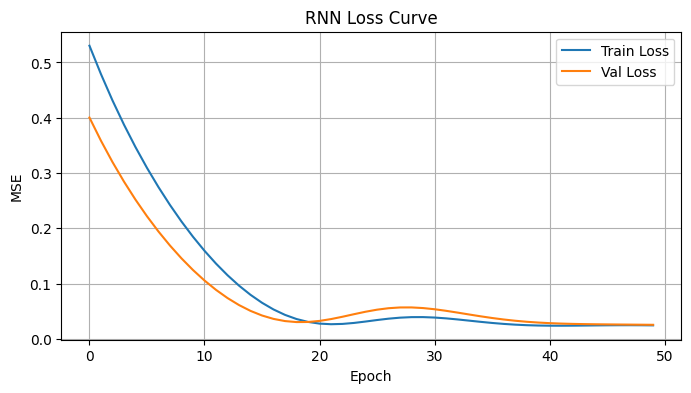

In [23]:
# Plot loss curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.title('RNN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.savefig('rnn_loss.png')
plt.show()

In [24]:
# Evaluate on test set
model.eval()
with torch.no_grad():
    pred_test = model(X_test_t).numpy()

# Convert back to original scale
pred_original = scaler.inverse_transform(pred_test)
y_original    = scaler.inverse_transform(y_test)

mae  = mean_absolute_error(y_original, pred_original)
rmse = np.sqrt(mean_squared_error(y_original, pred_original))

print(f'Simple RNN | MAE: {mae:.2f} | RMSE: {rmse:.2f}')

Simple RNN | MAE: 4.44 | RMSE: 5.06


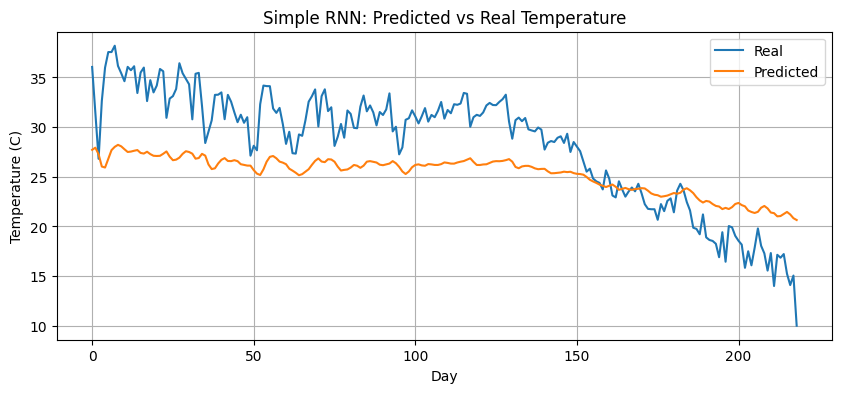

In [25]:
# Plot predictions vs real values
plt.figure(figsize=(10, 4))
plt.plot(y_original,    label='Real')
plt.plot(pred_original, label='Predicted')
plt.title('Simple RNN: Predicted vs Real Temperature')
plt.xlabel('Day')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid(True)
plt.savefig('rnn_predictions.png')
plt.show()